# Chapter 19 Lab — GLM Design Specification (Python)

Chapter 18 gave us the GLM machinery; this lab is about the *craft* of specifying the model. You will:

1. Build **event, epoch, and variable-duration** regressors and see how the choice changes the predictors
2. Add a **parametric modulator** and measure its collinearity with the average-response regressor using **variance inflation factors (VIFs)**
3. Run the **orthogonalization experiment**: see exactly which beta changes (and which does not) when you orthogonalize
4. Implement **high-pass filtering inside the GLM** with a cosine drift set, and measure how much *contrast* variance a filter removes
5. Add **motion covariates and spike regressors**, and check their impact on task VIFs

Because everything is simulated with known ground truth, you can see precisely what each modeling choice does to the parameter estimates.

**How to run this notebook.** Run it in your browser from the tutorial site, in Google Colab, or in a local Jupyter installation. It uses only `numpy`, `scipy`, `pandas`, `matplotlib`, and `nilearn`, and all data are simulated — nothing to download. It accompanies the [chapter page](../ch19-glm-design-specification.md).

**▶ This notebook is interactive.** Click the **⏻ power icon** at the top right of this page to run it in your browser — no installation needed (the kernel takes ~30–60 s to start the first time). Then run cells **top to bottom**, starting with the first code cell below: later cells depend on the imports and variables defined earlier, and will error if you skip ahead.

In [1]:
# Setup — needed when running in your browser or on Colab (safe to re-run anywhere)
%pip install -q nilearn


[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python3.11 -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from nilearn.glm.first_level import make_first_level_design_matrix
from nilearn.plotting import plot_design_matrix

np.set_printoptions(precision=3, suppress=True)

def canonical_hrf(t):
    # Double-gamma canonical HRF (SPM-style parameters), peak-normalized
    h = stats.gamma.pdf(t, 6, scale=1) - stats.gamma.pdf(t, 16, scale=1) / 6
    return h / h.max()

dt = 0.1                            # fine grid resolution (s) for convolution
t_r = 2.0                           # repetition time (s)
n_scans = 180                       # volumes
run_len = n_scans * t_r             # 360 s
frame_times = np.arange(n_scans) * t_r
t_hi = np.arange(0, run_len, dt)    # fine time grid
hrf = canonical_hrf(np.arange(0, 32, dt))
vol_idx = np.round(frame_times / dt).astype(int)

def make_regressor(onsets, durations, amplitudes=None):
    """Boxcar stimulus function (per-trial duration & amplitude) convolved
    with the canonical HRF, sampled at the volume acquisition times."""
    onsets = np.atleast_1d(np.asarray(onsets, float))
    durations = np.broadcast_to(np.asarray(durations, float), onsets.shape)
    if amplitudes is None:
        amplitudes = np.ones_like(onsets)
    stim = np.zeros_like(t_hi)
    for on, dur, amp in zip(onsets, durations, amplitudes):
        stim[(t_hi >= on) & (t_hi < on + dur)] = amp
    return np.convolve(stim, hrf)[: len(t_hi)][vol_idx]

print("Run: %d volumes, TR = %g s, %g s total" % (n_scans, t_r, run_len))

Run: 180 volumes, TR = 2 s, 360 s total


## 1. Event, epoch, and variable-duration regressors

The first modeling choice is how to represent each condition's neural activity:

- **Events**: brief impulses or short boxcars (a flashed picture, a button press)
- **Epochs**: sustained boxcars (a 16-s block of task)
- **Variable durations**: one boxcar per trial whose length tracks a process that varies from trial to trial — reaction time (RT) is the classic example

After HRF convolution these produce very different predictors, and the betas answer different questions. Below we model the *same 14 onsets* three ways: as 1-s events, as boxcars with a fixed (mean-RT) duration, and as boxcars with each trial's own RT.

corr(fixed-duration, variable-duration regressor) = 0.831


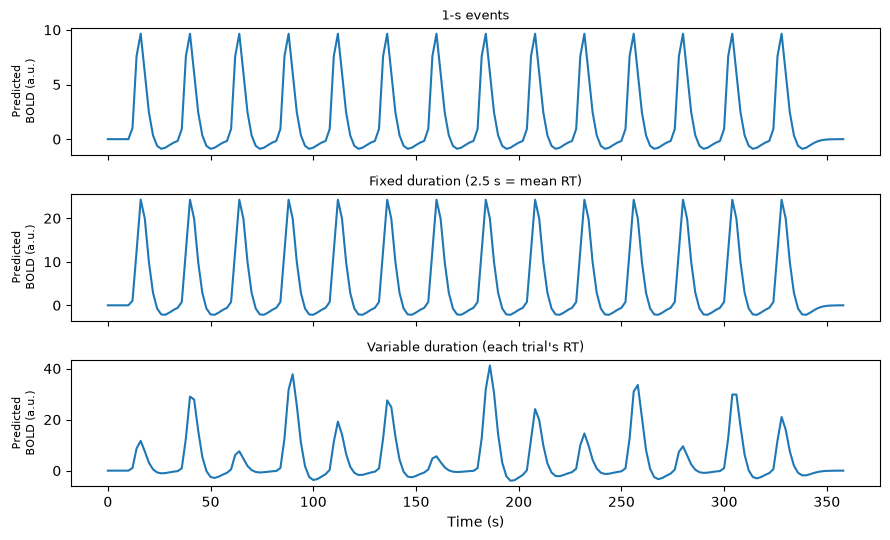

In [3]:
onsets = np.arange(10, 340, 24.0)     # one event type: 14 onsets, every 24 s
rt = np.array([1.2, 3.4, 0.8, 4.5, 2.0, 3.1, 0.6, 5.0,
               2.6, 1.5, 4.0, 1.0, 3.6, 2.2])   # per-trial RTs (s)

x_event  = make_regressor(onsets, 1.0)          # brief events
x_fixdur = make_regressor(onsets, rt.mean())    # fixed (mean-RT) duration
x_vardur = make_regressor(onsets, rt)           # variable duration (RT)

fig, axes = plt.subplots(3, 1, figsize=(9, 5.5), sharex=True)
for ax, x, ttl in [(axes[0], x_event,  "1-s events"),
                   (axes[1], x_fixdur, f"Fixed duration ({rt.mean():.1f} s = mean RT)"),
                   (axes[2], x_vardur, "Variable duration (each trial's RT)")]:
    ax.plot(frame_times, x, lw=1.5)
    ax.set_ylabel("Predicted\nBOLD (a.u.)", fontsize=8)
    ax.set_title(ttl, fontsize=9)
axes[2].set_xlabel("Time (s)")
plt.tight_layout()

r = np.corrcoef(x_fixdur, x_vardur)[0, 1]
print(f"corr(fixed-duration, variable-duration regressor) = {r:.3f}")

The three predictors share the same onsets but differ in shape and, for the variable-duration model, in trial-to-trial amplitude and width: long-RT trials produce larger, wider predicted responses. The fixed- and variable-duration regressors are highly correlated but not identical — the *difference* between them is exactly the RT-related information. Under linear-time-invariant assumptions, duration modulation and amplitude modulation are nearly indistinguishable for durations under ~1–2 s, and diverge as durations grow (long boxcars widen and plateau rather than just scaling up).

## 2. Parametric modulation

A **parametric modulator** asks a different question: does the response *amplitude* scale with a trial-by-trial variable — pain ratings, stimulus value, RT? The modulated regressor is entered **alongside** the unmodulated average-response regressor:

- the **average** beta captures the response to a typical event
- the **modulator** beta captures how the response scales with the variable

We build the modulator by weighting each trial's stimulus impulse by its rating before convolving. Crucially, we compare a **raw** (uncentered) modulator with a **mean-centered** one.

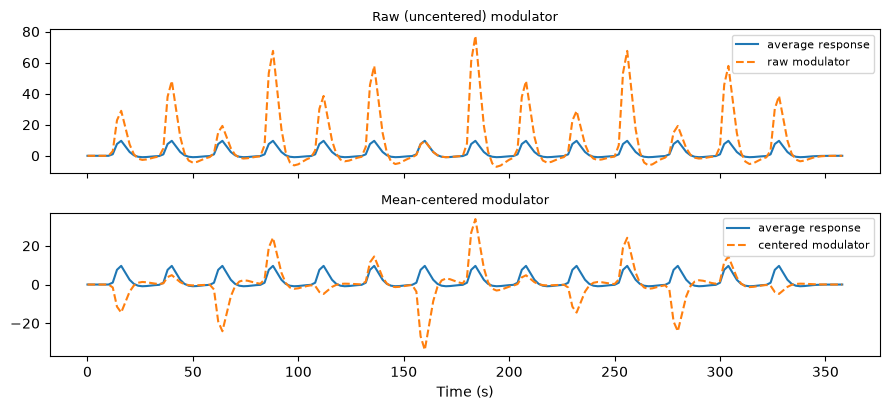

In [4]:
ratings = np.array([3, 5, 2, 7, 4, 6, 1, 8, 5, 3, 7, 2, 6, 4.0])  # 1 per trial

x_avg = make_regressor(onsets, 1.0)                              # average response
xmod_raw      = make_regressor(onsets, 1.0, ratings)             # raw modulator
xmod_centered = make_regressor(onsets, 1.0, ratings - ratings.mean())

fig, axes = plt.subplots(2, 1, figsize=(9, 4.2), sharex=True)
axes[0].plot(frame_times, x_avg, lw=1.5, label="average response")
axes[0].plot(frame_times, xmod_raw, lw=1.5, ls="--", label="raw modulator")
axes[0].legend(fontsize=8); axes[0].set_title("Raw (uncentered) modulator", fontsize=9)
axes[1].plot(frame_times, x_avg, lw=1.5, label="average response")
axes[1].plot(frame_times, xmod_centered, lw=1.5, ls="--", label="centered modulator")
axes[1].legend(fontsize=8); axes[1].set_title("Mean-centered modulator", fontsize=9)
axes[1].set_xlabel("Time (s)")
plt.tight_layout()

## 3. Collinearity: correlations and variance inflation factors

The modulator is built from the *same onsets* as its parent regressor, so the two are often substantially correlated. Pairwise correlations do not tell the whole story, though — what matters is whether one predictor can be written as a linear combination of *all* the others. The **variance inflation factor** captures this:

$$\mathrm{VIF}_i = \frac{1}{1 - R_i^2}$$

where $R_i^2$ comes from regressing predictor $i$ on all the other predictors. VIF = 1 is ideal; VIF = 2 means the variance of $\hat{\beta}_i$ has doubled relative to an orthogonal design. In fMRI, VIFs above ~4 warrant serious attention, and above 8 power suffers dramatically and effects are easily misattributed.

In [5]:
def vifs(X, names=None):
    """VIF for each column of X (task/nuisance regressors, no constant).
    Computed from the inverse of the correlation matrix, as in getvif.m."""
    X = np.asarray(X, float)
    v = np.diag(np.linalg.inv(np.corrcoef(X, rowvar=False)))
    return pd.Series(v, index=names if names is not None
                     else [f"x{i}" for i in range(X.shape[1])])

r_raw = np.corrcoef(x_avg, xmod_raw)[0, 1]
r_cen = np.corrcoef(x_avg, xmod_centered)[0, 1]
print(f"corr(avg, raw modulator)      = {r_raw:.2f}")
print(f"corr(avg, centered modulator) = {r_cen:.2f}\n")

tab = pd.DataFrame({
    "VIF (raw)":      vifs(np.column_stack([x_avg, xmod_raw])).to_numpy(),
    "VIF (centered)": vifs(np.column_stack([x_avg, xmod_centered])).to_numpy(),
}, index=["Average", "Modulator"])
print(tab.round(2))

corr(avg, raw modulator)      = 0.89
corr(avg, centered modulator) = -0.00

           VIF (raw)  VIF (centered)
Average         4.68             1.0
Modulator       4.68             1.0


Mean-centering is the essential first step, and it is what SPM and nilearn do by default. With evenly spaced onsets like these it removes essentially all of the collinearity (VIF → 1.0); with jittered or clustered onsets some usually remains. With the *raw* modulator, VIFs are already near 5: the average and modulated regressors carry nearly the same information, and neither beta can be estimated stably.

### Cross-check with nilearn

`make_first_level_design_matrix` accepts a `modulation` column in the events table. Give the average-response rows a modulation of 1 and the modulator rows the *centered* ratings, and it reproduces our hand-built pair.

In [6]:
ev  = pd.DataFrame({"onset": onsets, "duration": 1.0,
                    "trial_type": "pain", "modulation": 1.0})   # average response
mod = ev.assign(trial_type="pain_x_rating",
                modulation=ratings - ratings.mean())            # mean-center!

X_nl = make_first_level_design_matrix(frame_times,
                                      pd.concat([ev, mod], ignore_index=True),
                                      hrf_model="spm", drift_model=None)

for ours, name in [(x_avg, "pain"), (xmod_centered, "pain_x_rating")]:
    r = np.corrcoef(ours, X_nl[name])[0, 1]
    print(f"hand-built vs. nilearn '{name}': r = {r:.3f}")

[make_first_level_design_matrix] A 'modulation' column was found in the given events data and is used.
hand-built vs. nilearn 'pain': r = 1.000
hand-built vs. nilearn 'pain_x_rating': r = 1.000


## 4. The orthogonalization experiment

It is tempting to "fix" a correlated pair by **orthogonalizing** one regressor with respect to the other. SPM does this automatically for parametric modulators. But orthogonalization does not create information — it *reassigns the shared variance*. Let's prove it.

We simulate a voxel whose true response contains both an average effect ($\beta_{avg} = 1.0$) and a modulator effect ($\beta_{mod} = 0.5$), then fit the pair two ways — **as-is** and with the modulator **orthogonalized** with respect to the average regressor — using both the raw (highly correlated) and the mean-centered modulator.

Watch which beta changes and which does not.

In [7]:
rng = np.random.default_rng(42)
n = n_scans

# True voxel: average response (beta = 1.0) + rating-dependent scaling (beta = 0.5)
y = 100 + 1.0 * x_avg + 0.5 * xmod_centered + 2 * rng.standard_normal(n)

A = np.column_stack([x_avg, np.ones(n)])      # what we orthogonalize against

def orthogonalize(x):
    """Residuals of x after regressing out the average regressor + intercept."""
    return x - A @ np.linalg.lstsq(A, x, rcond=None)[0]

rows = {}
for label, xmod in [("raw modulator", xmod_raw),
                    ("centered modulator", xmod_centered)]:
    Xc = np.column_stack([x_avg, xmod,                np.ones(n)])   # as-is
    Xo = np.column_stack([x_avg, orthogonalize(xmod), np.ones(n)])   # orthogonalized
    b_c = np.linalg.lstsq(Xc, y, rcond=None)[0]
    b_o = np.linalg.lstsq(Xo, y, rcond=None)[0]
    rows[label] = [np.corrcoef(x_avg, xmod)[0, 1],
                   b_c[0], b_o[0], b_c[1], b_o[1]]

print(pd.DataFrame(rows, index=["corr(avg, modulator)",
                                "Average beta   -- as-is",
                                "Average beta   -- orthogonalized",
                                "Modulator beta -- as-is",
                                "Modulator beta -- orthogonalized"]).round(3))
print("\nTrue values: average = 1.0, modulator = 0.5")

                                  raw modulator  centered modulator
corr(avg, modulator)                      0.887              -0.000
Average beta   -- as-is                  -1.191               0.968
Average beta   -- orthogonalized          0.968               0.968
Modulator beta -- as-is                   0.480               0.480
Modulator beta -- orthogonalized          0.480               0.480

True values: average = 1.0, modulator = 0.5


**The modulator's beta is identical in both models** — in the correlated model it already reflects the unique (partial) effect of the modulator, controlling for the average response. What changed is the **average regressor's beta**. With the raw modulator the two regressors correlate at $r \approx 0.89$, and the as-is average beta is wildly off (even negative), because the raw modulator — whose mean rating is ~4.4 — is itself carrying the average response. Orthogonalizing hands that shared variance back to the average regressor and restores a sensible estimate. With the centered modulator the two regressors are already nearly orthogonal, so orthogonalization changes almost nothing: there was no shared variance to reassign.

Two lessons. First, **mean-center your modulators** — that fixes the real problem. Second, orthogonalization only decides *who gets credit* for shared variance. For a parametric modulator that is arguably right: the average regressor *should* get credit for the average response, and the modulator should capture only trial-to-trial scaling beyond it. But orthogonalizing an RT regressor with respect to condition regressors destroys its ability to control for RT confounds *across* conditions — the condition betas then still contain the RT-related variance. **Orthogonalize only when you have a principled reason to assign the shared variance to one regressor.**

## 5. High-pass filtering inside the GLM: the cosine drift set

fMRI signal drifts slowly even without a task (scanner instabilities, motion, aliased physiology), so most noise power lives at the lowest frequencies. Instead of pre-filtering the data (in which case the design matrix must be filtered identically!), we can add a **discrete cosine transform (DCT) basis** spanning all frequencies below the cutoff as columns of $X$. For a cutoff period of 128 s (the SPM default, 0.0078 Hz):

Cosine drift set: 6 columns (1 constant + 5 cosines)
                   drift          model  beta (true 1.0)    SE      t  df_e
 drift unrelated to task no drift model            1.024 0.079 12.969   178
 drift unrelated to task with drift set            1.016 0.045 22.542   173
drift correlated w/ task no drift model            1.199 0.116 10.360   178
drift correlated w/ task with drift set            1.059 0.045 23.502   173


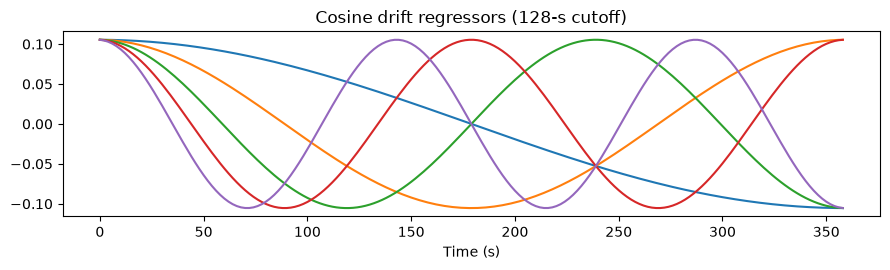

In [8]:
def dct_basis(n, run_len_s, cutoff_s=128.0):
    """SPM-style DCT drift matrix: constant + cosines below 1/cutoff Hz."""
    k = int(2 * run_len_s / cutoff_s + 1)          # number of basis functions
    t = np.arange(n)
    C = np.ones((n, k)) / np.sqrt(n)
    for j in range(1, k):
        C[:, j] = np.sqrt(2 / n) * np.cos(np.pi * (2 * t + 1) * j / (2 * n))
    return C                                        # column 0 is the constant

drift = dct_basis(n_scans, run_len, 128)
print(f"Cosine drift set: {drift.shape[1]} columns "
      f"(1 constant + {drift.shape[1]-1} cosines)")

fig, ax = plt.subplots(figsize=(9, 2.8))
ax.plot(frame_times, drift[:, 1:], lw=1.5)
ax.set(xlabel="Time (s)", title="Cosine drift regressors (128-s cutoff)")
plt.tight_layout()

def fit_task(X, y):
    """OLS fit; return the task beta (column 0), its SE, t, and df_e."""
    b = np.linalg.lstsq(X, y, rcond=None)[0]
    r = y - X @ b
    dfe = len(y) - X.shape[1]
    s2 = r @ r / dfe
    se = np.sqrt(s2 * np.diag(np.linalg.pinv(X.T @ X)))
    return b[0], se[0], b[0] / se[0], dfe

# Two kinds of drift: one unrelated to the task, one that happens to share
# the task's low-frequency structure (the projection of x_avg onto drift space)
P_drift = drift @ np.linalg.pinv(drift)
low = P_drift @ x_avg - (P_drift @ x_avg).mean()

scenarios = {
    "drift unrelated to task":  4 * np.sin(2 * np.pi * np.arange(n) / n * 1.5)
                                + np.linspace(0, -5, n),
    "drift correlated w/ task": 5 * low / low.std(),
}

res = []
for name, drift_sig in scenarios.items():
    y2 = 100 + 1.0 * x_avg + drift_sig + 2 * rng.standard_normal(n)
    for model, X in [("no drift model", np.column_stack([x_avg, np.ones(n)])),
                     ("with drift set", np.column_stack([x_avg, drift]))]:
        res.append((name, model) + fit_task(X, y2))

print(pd.DataFrame(res, columns=["drift", "model", "beta (true 1.0)",
                                 "SE", "t", "df_e"]).round(3).to_string(index=False))

Two things happen when drift is left unmodeled. Always, the slow noise lands in the residuals: $\hat{\sigma}^2$ is inflated, the standard error roughly doubles, and the t-statistic is roughly halved — a big power loss for five degrees of freedom. And whenever the drift shares structure with the task (bottom rows), the task beta is also **biased**, because the unmodeled drift has nowhere to go but the task regressor. Adding the cosine set makes the accounting explicit: drift columns explain the drift, task columns explain the task.

### What does the filter cost you? Check the *contrast*

Filtering is not free: any task variance below the cutoff is removed too. For block designs the rule of thumb is a cutoff period of roughly **twice the task period**. Event-related designs are trickier, because their variance is spread across frequencies — and what matters is the variance of the **contrasts** you care about, not just the individual regressors. Below we build randomized two-condition event-related designs and measure how much variance an 80-s filter removes from each regressor and from the A − B contrast.

this design -- variance removed from A               :   2.9%
this design -- variance removed from B               :   6.0%
this design -- variance removed from A - B contrast  :   4.8%



Over 200 random orderings (% variance removed by the 80-s filter):
        A     B  A - B
50%  14.1  13.4   13.4
90%  23.6  22.4   23.2
max  32.8  31.9   32.9
orderings where the contrast loses more than either regressor: 21%


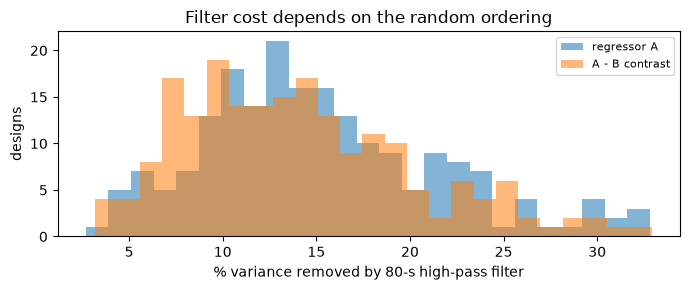

In [9]:
rng2 = np.random.default_rng(3)

def random_design():
    """28 jittered events, randomly labelled A or B."""
    ons = np.sort(rng2.uniform(8, run_len - 20, 28))
    lab = rng2.permutation(np.array(["A"] * 14 + ["B"] * 14))
    return make_regressor(ons[lab == "A"], 1.0), make_regressor(ons[lab == "B"], 1.0)

D = dct_basis(n_scans, run_len, cutoff_s=80)     # 80-s filter
P = D @ np.linalg.pinv(D)                        # projection onto drift space

def pct_var_removed(x):
    xf = x - P @ x                               # filtered regressor
    xc = x - x.mean()
    return 100 * (1 - (xf @ xf) / (xc @ xc))

# One design in detail, then the distribution over 200 random orderings
x_A, x_B = random_design()
for name, x in [("A", x_A), ("B", x_B), ("A - B contrast", x_A - x_B)]:
    print(f"this design -- variance removed from {name:16s}: {pct_var_removed(x):5.1f}%")

loss = np.array([[pct_var_removed(a), pct_var_removed(b), pct_var_removed(a - b)]
                 for a, b in (random_design() for _ in range(200))])

summary = pd.DataFrame(loss, columns=["A", "B", "A - B"]).describe(
    percentiles=[0.5, 0.9]).loc[["50%", "90%", "max"]].round(1)
print("\nOver 200 random orderings (% variance removed by the 80-s filter):")
print(summary)
print(f"orderings where the contrast loses more than either regressor: "
      f"{100 * np.mean(loss[:, 2] > loss[:, :2].max(axis=1)):.0f}%")

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(loss[:, 0], bins=25, alpha=0.55, label="regressor A")
ax.hist(loss[:, 2], bins=25, alpha=0.55, label="A - B contrast")
ax.set(xlabel="% variance removed by 80-s high-pass filter",
       ylabel="designs", title="Filter cost depends on the random ordering")
ax.legend(fontsize=8)
plt.tight_layout()

The first design we drew was a lucky one: the 80-s filter cost its contrast under 5% of its variance. Across 200 random orderings, though, the median contrast loss is ~13% — close to the ~12% in the book's example — and the spread is wide, and in roughly one design in five the *contrast* loses more than either regressor does. That happens when the random ordering leaves slow stretches that are A-heavy or B-heavy, putting contrast energy below the cutoff. Filtering buys power only when it removes more noise than task-related signal, so check the cost on the contrasts you actually plan to test — before you collect data, when you can still re-randomize the design (Chapter 27).

## 6. Motion covariates, spike regressors, and task VIFs

Finally we assemble a realistic first-level design: task regressors plus **nuisance covariates** —

- six realignment parameters (simulated here as slow random walks; real pipelines often expand them to 24 with squares and derivatives)
- **spike regressors**: one indicator column per artifact-contaminated volume (flagged by framewise displacement, DVARS, or Mahalanobis distance). Spike regression absorbs all of a bad volume's variance and is preferred to deleting volumes because it preserves the temporal structure needed for valid variances and P values
- the cosine drift set from Section 5

Correlations *among* nuisance regressors are harmless — we never interpret their betas. What matters is **nuisance–task** correlation, which inflates the task VIFs. Comparing task VIFs with and without the nuisance set is a quick, powerful diagnostic you can run before ever touching brain data.

           task alone  full model
avg               1.0        1.04
modulator         1.0        1.13


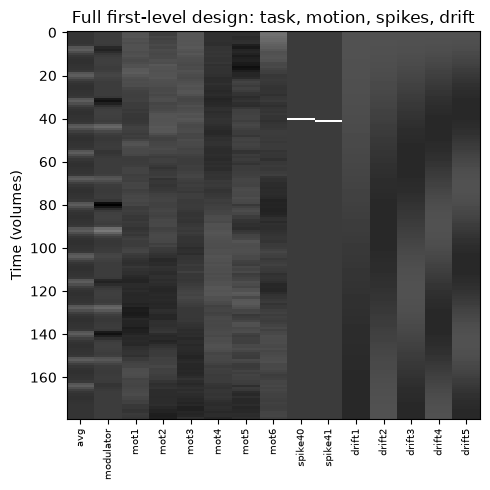

In [10]:
mot = np.cumsum(rng.standard_normal((n, 6)) * 0.02, axis=0)   # motion params

bad_vols = [40, 41]                                   # flagged volumes
spikes = np.zeros((n, len(bad_vols)))
for j, v in enumerate(bad_vols):
    spikes[v, j] = 1.0

X_task = np.column_stack([x_avg, xmod_centered])
X_full = np.column_stack([X_task, mot, spikes, drift[:, 1:]])  # + cosines
names_full = (["avg", "modulator"] + [f"mot{i+1}" for i in range(6)]
              + [f"spike{v}" for v in bad_vols]
              + [f"drift{i+1}" for i in range(drift.shape[1] - 1)])

v_alone = vifs(X_task, ["avg", "modulator"])
v_full  = vifs(X_full, names_full)
print(pd.DataFrame({"task alone": v_alone,
                    "full model": v_full[["avg", "modulator"]]}).round(2))

fig, ax = plt.subplots(figsize=(5, 5))
Z = (X_full - X_full.mean(0)) / X_full.std(0)
ax.imshow(Z, aspect="auto", cmap="gray", interpolation="nearest")
ax.set(xticks=range(len(names_full)), xlabel="", ylabel="Time (volumes)",
       title="Full first-level design: task, motion, spikes, drift")
ax.set_xticklabels(names_full, rotation=90, fontsize=7)
plt.tight_layout()

Here the task VIFs barely move: simulated motion and drift are (by construction) nearly unrelated to the task, so the nuisance set is cheap insurance. With real data, motion is often task-correlated (people move when they respond, swallow at block boundaries) — task VIFs then jump, and significance rightly drops, because task and artifact are genuinely confounded.

Every nuisance column also costs one error degree of freedom: with 180 volumes and this design we still have plenty, but with 24 motion covariates + CompCor + many spikes in a short run, $df_e$ can erode quickly. Less aggressive strategies with fewer regressors are often preferred.

## Where to go next

- **Autocorrelated errors:** the residuals of every model above are still autocorrelated — AR models, prewhitening, and generalized least squares make first-level P values valid
- **Chapter 20:** contrasts and inference — coding and testing any comparison of conditions
- **Chapter 27:** design efficiency — choosing onsets and orderings that keep VIFs low and contrast variance high *before* you scan

**Exercises**

1. Make one motion regressor task-correlated (`mot[:, 0] += 0.1 * x_avg`) and re-run Section 6. What happens to the task VIFs? Simulate data and check what happens to the task betas' standard errors.
2. Halve the filter cutoff in Section 5 (64 s). How many drift columns are added, how many $df_e$ are lost, and how much more contrast variance is removed?
3. In Section 4, orthogonalize the *average* regressor with respect to the modulator instead. Which beta is unchanged now? Explain why in terms of shared-variance assignment.
4. Build a variable-duration RT regressor (Section 1) *and* an RT parametric modulator for the same trials, and compute the VIF of each with the average regressor in the model. Which representation is more separable from the average response, and why?